In [1]:
import pathlib

import numpy as np
import pandas as pd

In [2]:
from trait_prediction.main import PhenotypeSet, PhenotypeIndex
from trait_prediction.utils import (
    read_interpro_features,
    read_rast_features,
)

## Reading the data


In [3]:
data_folder = pathlib.Path("../data/raw/")

metabolic_phenotype_file = data_folder / "metabolic_phenotypes_bacdive.tsv"
non_metabolic_phenotype_file = data_folder / "non_metabolic_phenotypes_bacdive.tsv"
rast_feature_file = data_folder / "rast_features.tsv"
interpro_feature_file = data_folder / "interpro_features.tsv"

In [4]:
metabolic_phenotypeset = PhenotypeSet.read_data(str(metabolic_phenotype_file))
non_metabolic_phenotypeset = PhenotypeSet.read_data(str(non_metabolic_phenotype_file))

In [5]:
rast_features, rast_sso_dict = read_rast_features(rast_feature_file)
interpro_features, interpro_ipr_dict = read_interpro_features(interpro_feature_file)

In [6]:
glucose_index = PhenotypeIndex(name="glucose", category="carbon_source")
glucose_phenotype = metabolic_phenotypeset[glucose_index]
glucose_phenotype.set_feature_data(rast_features, "rast")

In [19]:
glucose_phenotype

Phenotype (name=glucose, category=carbon_source, size=1606)

## Machine learning using the RAST annotations


In [20]:
from collections import Counter

counter = Counter(glucose_phenotype.phenotype_data)
counter

Counter({1: 1582, 0: 24})

In [21]:
low_var_features, correlated_features_dict = glucose_phenotype.filter_feature_data(
    variance_threshold=0.05, correlation_treshold=0.95
)

In [22]:
from catboost import CatBoostClassifier

In [23]:
random_state = 42

In [24]:
clf = CatBoostClassifier(
    iterations=1000,
    depth=6,
    learning_rate=0.1,
    random_state=random_state,
    verbose=False,
)

In [25]:
from trait_prediction.training import PhenotypePredictor

In [26]:
phenotype_predictor = PhenotypePredictor(
    glucose_phenotype, clf, random_state=random_state
)

In [27]:
data = phenotype_predictor.split_data(test_size=0.3, stratify=True, imbalanced="auto")

Performing Oversampling...


In [30]:
data.keys()

dict_keys(['X_train', 'X_test', 'y_train', 'y_test'])

In [38]:
phenotype_predictor.fit()

In [39]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report,
)

In [40]:
y_pred = phenotype_predictor.predict()

In [41]:
y_true = data["y_test"]

In [42]:
confusion_matrix(y_true, y_pred)

array([[  0,   7],
       [  2, 473]])

In [43]:
f1_score(y_true, y_pred, average="weighted")

0.9761899589407139

## SHAP values


In [44]:
import shap

Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)


In [45]:
explainer = shap.Explainer(clf)

In [46]:
shap_values = explainer.shap_values(data["X_train"])

No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


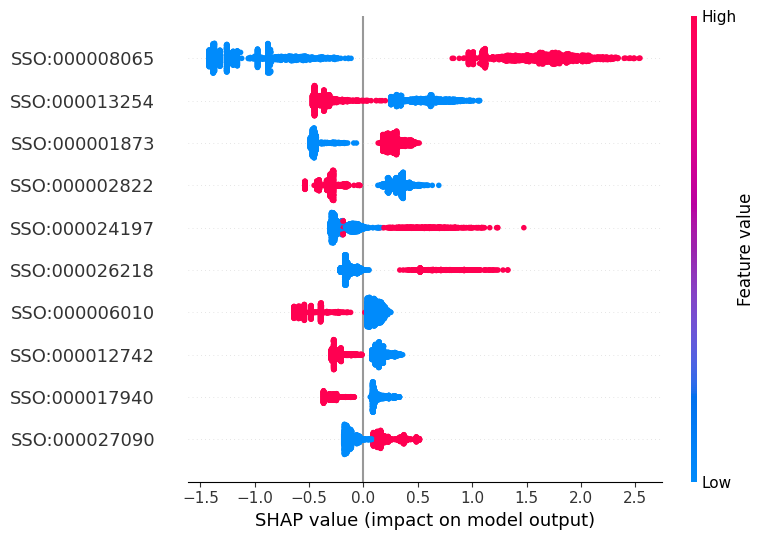

In [47]:
shap.summary_plot(shap_values, data["X_train"], max_display=10)

In [49]:
shap.summary_plot(shap_values, data["X_train"], type="bar")

TypeError: summary_legacy() got an unexpected keyword argument 'type'

In [ ]:
rast_sso_dict["SSO:000008065"], rast_sso_dict["SSO:000013254"], rast_sso_dict[
    "SSO:000001873"
],

('Thymidine kinase (EC 2.7.1.21)',
 'DsrE family protein',
 'Cytidine deaminase (EC 3.5.4.5)')